<a href="https://colab.research.google.com/github/Bloop15/DL-2026-2027/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
(x_train, _), (x_test, _)= tf.keras.datasets.mnist.load_data()

x_train= x_train.astype("float32")/255.0
x_test=  x_test.astype("float32")/255.0

x_train= x_train[..., np.newaxis]
x_test= x_test[..., np.newaxis]

print("Training shape: ", x_train.shape)
print("Testing shape : ", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape:  (60000, 28, 28, 1)
Testing shape :  (10000, 28, 28, 1)


In [3]:
def add_noise(x):
    noise= 0.5*np.random.randn(*x.shape)
    noisy= x+noise
    return np.clip(noisy, 0., 1.)

x_train_noisy= add_noise(x_train)
x_test_noisy= add_noise(x_test)

In [4]:
encoder= models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

decoder= models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

encoder.summary()
decoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,240 (196.25 KB)

 Trainable params: 50,240 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,960 (199.06 KB)

 Trainable params: 50,960 (199.06 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
ucae= models.Sequential([encoder,decoder])

ucae.compile(optimizer='adam',loss='binary_crossentropy')
ucae.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_ucae= ucae.fit(x_train,x_train,epochs=5,batch_size=256,validation_data=(x_test, x_test),verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2447 - val_loss: 0.1642
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1459 - val_loss: 0.1276
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1182 - val_loss: 0.1080
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1035 - val_loss: 0.0974
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0945 - val_loss: 0.0899


In [7]:
d_encoder= models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

d_decoder= models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

dnae= models.Sequential([d_encoder,d_decoder])

dnae.compile(optimizer='adam',loss='binary_crossentropy')
dnae.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_dnae = dnae.fit(x_train_noisy,x_train,epochs=5,batch_size=256,validation_data=(x_test_noisy, x_test),verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2611 - val_loss: 0.1962
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1775 - val_loss: 0.1625
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1544 - val_loss: 0.1453
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1409 - val_loss: 0.1347
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1325 - val_loss: 0.1288


In [9]:
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var= inputs
        epsilon= tf.random.normal(shape=tf.shape(z_mean))

        return z_mean+tf.exp(0.5*z_log_var)*epsilon

In [11]:
latent_dim= 2

vae_inputs= layers.Input(shape=(28, 28, 1))

x= layers.Flatten()(vae_inputs)
x= layers.Dense(128, activation='relu')(x)

z_mean= layers.Dense(latent_dim, name='z_mean')(x)
z_log_var= layers.Dense(latent_dim, name='z_log_var')(x)

z= Sampling()([z_mean, z_log_var])

vae_encoder= tf.keras.Model(vae_inputs,[z_mean, z_log_var, z],name='vae_encoder')
vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 784)       │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │    100,480 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
latent_inputs= layers.Input(shape=(latent_dim,))

x= layers.Dense(128, activation='relu')(latent_inputs)
x= layers.Dense(784, activation='sigmoid')(x)

vae_outputs= layers.Reshape((28, 28, 1))(x)

vae_decoder= tf.keras.Model(latent_inputs,vae_outputs,name='vae_decoder')
vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder= encoder
        self.decoder= decoder

    def call(self, inputs):

        z_mean, z_log_var, z= self.encoder(inputs)
        reconstruction= self.decoder(z)

        recon_loss= tf.reduce_mean(tf.keras.losses.binary_crossentropy(inputs, reconstruction))*784
        kl_loss= -0.5*tf.reduce_mean(1+z_log_var-tf.square(z_mean)-tf.exp(z_log_var))
        total_loss= recon_loss+kl_loss

        self.add_loss(total_loss)

        return reconstruction

In [14]:
vae= VAE(vae_encoder, vae_decoder)
vae.compile(optimizer='adam')

history_vae= vae.fit(x_train,x_train,epochs=5,batch_size=256,validation_data=(x_test, x_test),verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 235.6520 - val_loss: 191.0957
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 186.9253 - val_loss: 182.9743
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 180.0648 - val_loss: 176.2870
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 172.2262 - val_loss: 169.5917
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 167.7762 - val_loss: 166.9791


In [15]:
def show_imgs(original, reconstructed, title):

    plt.figure(figsize=(10, 4))
    n= min(10, len(original))

    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(original[i].squeeze(), cmap='gray')
        plt.axis('off')

        plt.subplot(2, n, i + n + 1)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


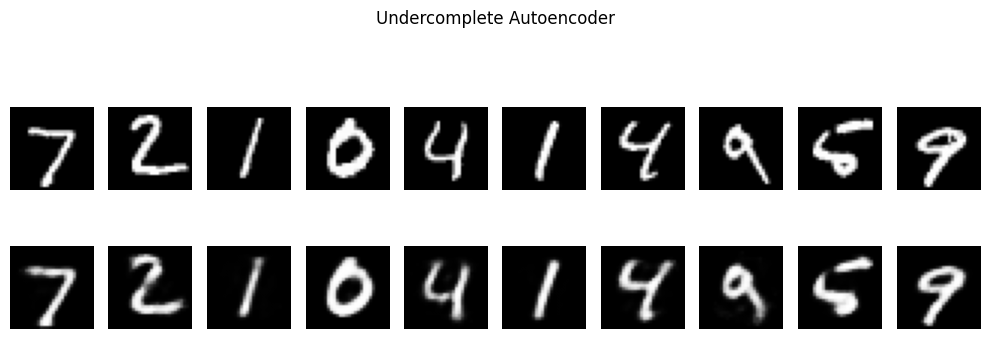

In [16]:
ucae_recon= ucae.predict(x_test)

show_imgs(x_test,ucae_recon,"Undercomplete Autoencoder")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


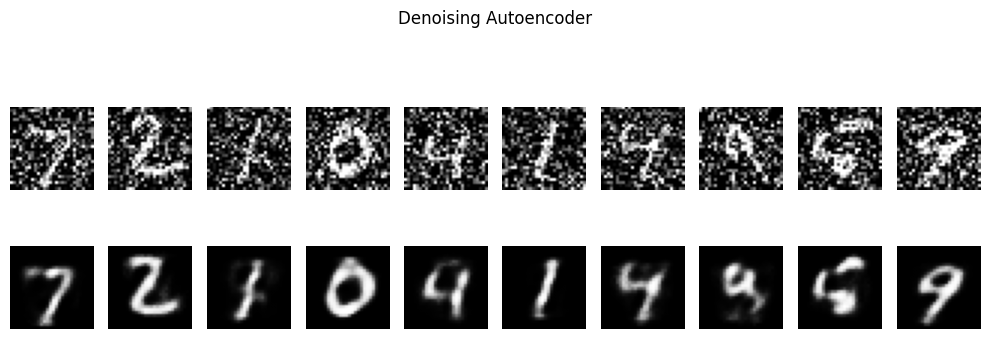

In [17]:
dnae_recon= dnae.predict(x_test_noisy)

show_imgs(x_test_noisy,dnae_recon,"Denoising Autoencoder")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


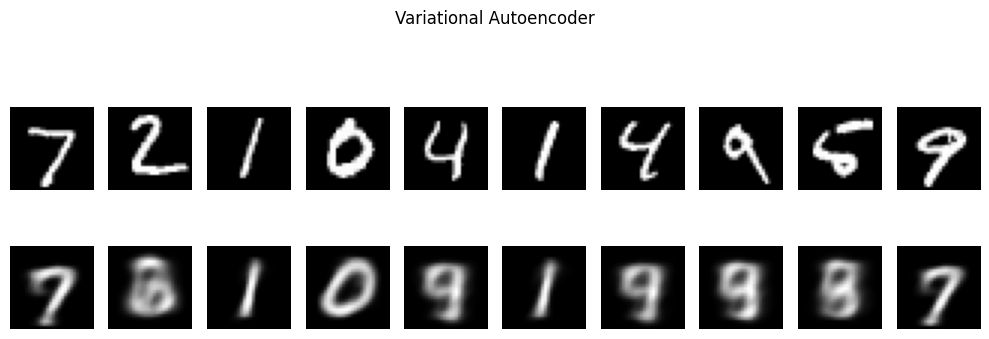

In [18]:
vae_recon= vae.predict(x_test)

show_imgs(x_test,vae_recon,"Variational Autoencoder")